# Attrition Prediction — EDA & Model Comparison

Exploratory analysis of the seed dataset (real IBM HR Analytics Employee Attrition & Performance data, 1,470 employees), a check that synthetic augmentation preserves its statistics, and a comparison of the models tracked in MLflow by `ml/training/train.py`.

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("repo root not found")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "backend"))

import matplotlib.pyplot as plt
import pandas as pd

from ml.etl.clean import clean
from ml.etl.extract import extract
from ml.etl.schema import RawAttritionSchema
from ml.etl.synthetic import augment
from ml.training.data import DEFAULT_SEED_PATH

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (7, 4)

## 1. Load and validate the real seed data

In [2]:
raw_df = extract(DEFAULT_SEED_PATH)
seed_df = RawAttritionSchema.validate(raw_df, lazy=True)
seed_df = clean(seed_df)
print(f"{len(seed_df)} employees, {seed_df.shape[1]} columns")
seed_df.head()

1470 employees, 32 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,is_outlier
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,8,Yes,11,3,1,0,8,0,1,6,4,0,5,False
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,1,No,23,4,4,1,10,3,3,10,7,1,7,False
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,6,Yes,15,3,2,0,7,3,3,0,0,0,0,False
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,1,Yes,11,3,3,0,8,3,3,8,7,3,0,False
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,9,No,12,3,4,1,6,3,3,2,2,2,2,False


In [3]:
seed_df[
    [
        "Age",
        "MonthlyIncome",
        "DistanceFromHome",
        "TotalWorkingYears",
        "YearsAtCompany",
        "JobSatisfaction",
        "WorkLifeBalance",
    ]
].describe()

,Age,MonthlyIncome,DistanceFromHome,TotalWorkingYears,YearsAtCompany,JobSatisfaction,WorkLifeBalance
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,6502.931293,9.192517,11.279592,7.008163,2.728571,2.761224
std,9.135373,4707.956783,8.106864,7.780782,6.126525,1.102846,0.706476
min,18.000000,1009.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,30.000000,2911.000000,2.000000,6.000000,3.000000,2.000000,2.000000
50%,36.000000,4919.000000,7.000000,10.000000,5.000000,3.000000,3.000000
75%,43.000000,8379.000000,14.000000,15.000000,9.000000,4.000000,3.000000
max,60.000000,19999.000000,29.000000,40.000000,40.000000,4.000000,4.000000


## 2. Attrition rate, overall and by key drivers

In [4]:
overall_rate = (seed_df["Attrition"] == "Yes").mean()
print(f"Overall attrition rate: {overall_rate:.1%}")

Overall attrition rate: 16.1%


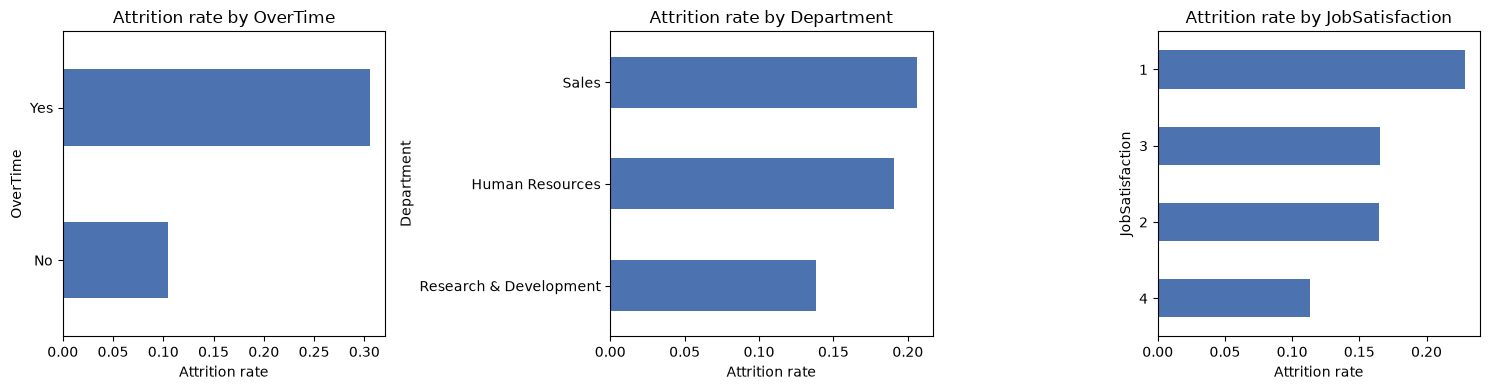

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(axes, ["OverTime", "Department", "JobSatisfaction"], strict=False):
    rates = seed_df.groupby(column)["Attrition"].apply(lambda s: (s == "Yes").mean())
    rates.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_xlabel("Attrition rate")
    ax.set_title(f"Attrition rate by {column}")

fig.tight_layout()

## 3. Does synthetic augmentation preserve the real statistics?

In [6]:
augmented_df = augment(seed_df, target_rows=8000, random_state=42)
augmented_rate = (augmented_df["Attrition"] == "Yes").mean()

comparison = pd.DataFrame(
    {
        "n_rows": [len(seed_df), len(augmented_df)],
        "attrition_rate": [overall_rate, augmented_rate],
        "mean_monthly_income": [
            seed_df["MonthlyIncome"].mean(),
            augmented_df["MonthlyIncome"].mean(),
        ],
    },
    index=["real seed", "seed + synthetic"],
)
comparison

,n_rows,attrition_rate,mean_monthly_income
real seed,1470,0.161224,6502.931293
seed + synthetic,8000,0.160250,6444.966125


The attrition rate and mean income stay close after scaling ~5x — the bootstrap+jitter approach (resample a real row, perturb it, rather than resampling each column independently) preserves the real joint distribution instead of just matching marginals.

## 4. Model comparison (from MLflow)

In [7]:
import mlflow

from ml.training.mlflow_utils import EXPERIMENT_NAME, REGISTERED_MODEL_NAME, TRACKING_URI

mlflow.set_tracking_uri(TRACKING_URI)
runs_df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
metric_cols = [c for c in runs_df.columns if c.startswith("metrics.")]
comparison_table = (
    runs_df[["tags.mlflow.runName", *metric_cols]]
    .rename(columns=lambda c: c.replace("metrics.", "").replace("tags.mlflow.runName", "model"))
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
comparison_table

,model,roc_auc,accuracy,recall,cv_roc_auc_std,precision,f1,cv_roc_auc_mean
0,xgboost,0.795818,0.844,0.24375,0.043626,0.527027,0.333333,0.811715
1,lightgbm,0.786563,0.850,0.16250,0.048241,0.619048,0.257426,0.806392
2,neural_network,0.783780,0.858,0.33750,0.052356,0.600000,0.432000,0.816715
3,catboost,0.778802,0.856,0.15625,0.052515,0.735294,0.257732,0.807811
4,random_forest,0.778423,0.852,0.13125,0.051927,0.700000,0.221053,0.799748
5,logistic_regression,0.777046,0.865,0.31250,0.051254,0.666667,0.425532,0.833223


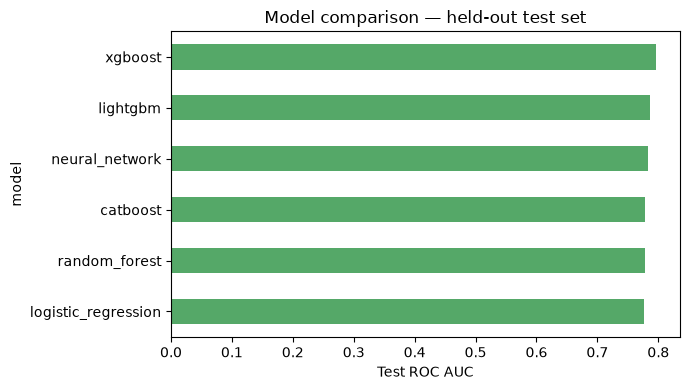

In [8]:
comparison_table.set_index("model")["roc_auc"].sort_values().plot(
    kind="barh", color="#55A868", figsize=(7, 4)
)
plt.xlabel("Test ROC AUC")
plt.title("Model comparison — held-out test set")
plt.tight_layout()

## 5. The registered (champion) model

In [9]:
client = mlflow.MlflowClient()
champion = client.get_model_version_by_alias(REGISTERED_MODEL_NAME, "staging")
champion_run = client.get_run(champion.run_id)

print(f"Registered model: {REGISTERED_MODEL_NAME} v{champion.version}")
print(f"Source run: {champion_run.data.tags.get('mlflow.runName')} ({champion.run_id})")
print("Metrics:")
for key, value in champion_run.data.metrics.items():
    print(f"  {key}: {value:.4f}")

Registered model: attrition-classifier v1
Source run: xgboost (0f5e335486054f98b3247805431bd544)
Metrics:
  accuracy: 0.8440
  precision: 0.5270
  recall: 0.2437
  f1: 0.3333
  roc_auc: 0.7958
  cv_roc_auc_mean: 0.8117
  cv_roc_auc_std: 0.0436


/Users/simensimenmartial/Library/Caches/pypoetry/virtualenvs/ai-employee-retention-platform-jtsdgL0N-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


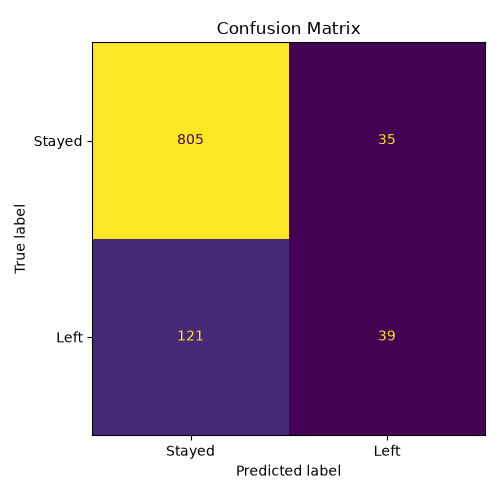

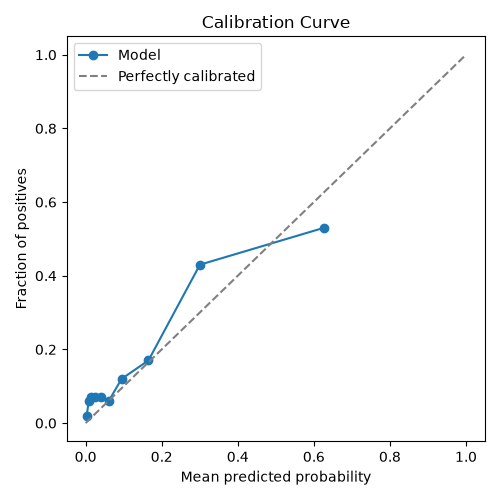

In [10]:
import tempfile

from IPython.display import Image, display

with tempfile.TemporaryDirectory() as tmp:
    for artifact_name in ["confusion_matrix.png", "calibration_curve.png"]:
        local_path = client.download_artifacts(champion.run_id, artifact_name, tmp)
        display(Image(local_path))

## Methodology note: avoiding synthetic-augmentation leakage

Early runs scored suspiciously high (ROC AUC ~0.99). The cause: bootstrap+jitter synthetic rows are close relatives of the real row they were resampled from, and a plain stratified train/test split let a row and its near-duplicate land on opposite sides of the split — the model was partly recognizing near-duplicates, not learning the underlying pattern. `ml/etl/synthetic.py` now tags every row with a `lineage_id` (the real employee it traces back to), and `ml/training/train.py` uses `StratifiedGroupKFold` for both the train/test split and every cross-validation fold, keeping a lineage entirely on one side. The corrected scores (~0.78-0.80 ROC AUC) line up with published benchmarks for this real dataset.